# 📊 EDA & KPI Overview — Nordic Weekly Top 10 Dataset (Sweden, Norway, Denmark, Finland, Iceland) - Aira
“We evaluate content performance across Nordic markets using ranking-based metrics that capture strength, consistency, and long-term impact.”

# 🚀 Core KPI Framework

* **performance_score** → strength (how well it ranked)
* **appearances** → consistency (how often it appeared)
* **avg_rank** → quality (average position)
* **longevity** → lifecycle (long-term success)

---

| Category                   | Grain                  | KPI / Analysis                             | What it Answers                               | Example Use           |
| -------------------------- | ---------------------- | ------------------------------------------ | --------------------------------------------- | --------------------- |
| **Data Overview**          | Country                | Total rows, countries, time range          | What is the scope per Nordic market?          | Sanity check          |
| **Monthly Leaders**        | Country + Year + Month | Top 10 shows per month                     | Which shows dominated each month?             | Bar chart             |
| **Monthly Winner**         | Country + Year + Month | Top 1 show (highest performance_score)     | Who was #1 each month?                        | Storytelling          |
| **Yearly Leaders**         | Country + Year         | Top 10 shows per year                      | Which shows dominated the entire year?        | Bar chart             |
| **Performance Strength**   | Show + Month           | performance_score = SUM(11 - rank)         | How strong was a show’s ranking performance?  | Ranking metric        |
| **Consistency**            | Show + Month           | appearances (COUNT of weeks)               | How often did the show appear in Top 10?      | Stability indicator   |
| **Ranking Quality**        | Show + Month           | avg_rank                                   | How high did the show rank on average?        | Quality metric        |
| **Longevity**              | Show                   | cumulative_weeks_in_top_10 (MAX)           | Is the show a long-term hit?                  | Lifecycle signal      |
| **Country Comparison**     | Country + Year         | Top shows per country                      | Do Nordic countries share the same hits?      | Cross-market analysis |
| **Market Preference**      | Country + Month        | Distribution of top shows                  | Does each country favor different content?    | Behavioral insight    |
| **Dominance Analysis**     | Show + Year            | yearly performance_score                   | Which shows dominate across the full year?    | Leaderboard           |
| **Trend Evolution**        | Show + Time            | performance_score over time                | Is a show rising, stable, or declining?       | Line chart            |
| **Hit Identification**     | Show + Country         | High score + high appearances              | What defines a “hit” in each market?          | KPI classification    |
| **Volatility / Stability** | Show                   | variation in rank (avg_rank + appearances) | Is performance stable or fluctuating?         | Risk/consistency      |
| **Nordic Overlap**         | Show + Countries       | Count distinct countries                   | Is this a regional (Nordic) hit or local hit? | Strategic insight     |

---


## Nordic Country Focused Analysis using the global_weekly dataset

## 🎯 Context (Important)

Each row in dataset =
👉 One show in the Top 10
👉 In one country
👉 For one week

So everything calculated is based on **how often and how well a show appears in the Top 10**.

---

# 🧠 1. Appearances

## Definition

Number of weeks a show showed up in the Top 10 during a month.

```sql
COUNT(*)
```

## Simple Explanation

👉 “How many times did this show show up this month?”

## Example

* Appears 4 weeks → appearances = 4
* Appears 1 week → appearances = 1

## What it tells you

* High → show stayed popular for many weeks
* Low → show appeared briefly

---

# 🧠 2. Performance Score

## Definition

A score based on ranking position.

```sql
SUM(11 - weekly_rank)
```

## Simple Explanation

👉 “How strong was the show when it appeared?”

* Rank 1 = 10 points (very strong)
* Rank 10 = 1 point (weak)

## Example

| Week | Rank | Points |
| ---- | ---- | ------ |
| 1    | 1    | 10     |
| 2    | 3    | 8      |
| 3    | 5    | 6      |

Total performance_score = 24

## What it tells you

* High → strong performance (top ranks)
* Low → weak performance (bottom ranks)

---

# 🧠 3. Longevity

## Definition

The maximum total weeks a show has ever been in the Top 10.

```sql
MAX(cumulative_weeks_in_top_10)
```

## Simple Explanation

👉 “Is this a long-lasting hit or just a short trend?”

## Example

* 20 weeks → very popular long-term
* 2 weeks → short-lived

## What it tells you

* High → long-term success
* Low → new or temporary

---

# 🧠 4. Average Rank

## Definition

Average position of the show during the month.

```sql
AVG(weekly_rank)
```

## Simple Explanation

👉 “On average, how high did the show rank?”

## Example

* Avg rank = 2 → very strong
* Avg rank = 8 → weak

## What it tells you

* Lower = better
* Higher = worse

---

# 🔥 Putting It All Together

Each metric shows something different:

| KPI               | Simple Meaning            |
| ----------------- | ------------------------- |
| appearances       | how often it showed up    |
| performance_score | how strong it was         |
| longevity         | how long it lasts overall |
| avg_rank          | how high it ranked        |

---

## Load Data

In [1]:
import pandas as pd
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import openpyxl
print("openpyxl is working") # for reading excel files

openpyxl is working


In [2]:
DATA_PATH = Path("../../data/raw")

print(DATA_PATH)
print(DATA_PATH.exists())

df = pd.read_excel(DATA_PATH / "global_weekly.xlsx")

..\..\data\raw
True


c:\Users\adelo\de25\Netflix_Analytics_DE_UX\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## Inspect DataFrame and Table

In [3]:
df.head()

,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2026-03-15,Films,1,War Machine,NaN,2
1,Argentina,AR,2026-03-15,Films,2,Strangers in the Park,NaN,2
2,Argentina,AR,2026-03-15,Films,3,Joker: Folie à Deux,NaN,1
3,Argentina,AR,2026-03-15,Films,4,Trolls Band Together,NaN,2
4,Argentina,AR,2026-03-15,Films,5,Double Jeopardy,NaN,1


In [4]:
df.shape

(458260, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458260 entries, 0 to 458259
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   country_name                458260 non-null  object
 1   country_iso2                458260 non-null  object
 2   week                        458260 non-null  object
 3   category                    458260 non-null  object
 4   weekly_rank                 458260 non-null  int64 
 5   show_title                  458260 non-null  object
 6   season_title                223904 non-null  object
 7   cumulative_weeks_in_top_10  458260 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 28.0+ MB


## Check for NULLS and duplicates

In [6]:
df.isnull().sum()

country_name                       0
country_iso2                       0
week                               0
category                           0
weekly_rank                        0
show_title                         0
season_title                  234356
cumulative_weeks_in_top_10         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Describe

In [8]:
df.describe()

,weekly_rank,cumulative_weeks_in_top_10
count,458260.000000,458260.000000
mean,5.500000,3.442231
std,2.872284,6.057246
min,1.000000,1.000000
25%,3.000000,1.000000
50%,5.500000,2.000000
75%,8.000000,3.000000
max,10.000000,127.000000


In [9]:
df["category"].value_counts()

category
Films    229130
TV       229130
Name: count, dtype: int64

## Convert week to datetime

In [10]:
# Convert week to datetime
df["week"] = pd.to_datetime(df["week"])

# Create date helper columns
df["year"] = df["week"].dt.year
df["month"] = df["week"].dt.month
df["month_start"] = df["week"].values.astype("datetime64[M]")

# Register in DuckDB
duckdb.register("global_weekly", df)

# Confirm
duckdb.sql("SHOW TABLES").df()

,name
0,global_weekly


## Country-level Analysis 
Which countries have the highest Top 10 activity, strongest diversity, and most stable rankings?

In [11]:
country_kpi_df = duckdb.sql("""
SELECT
    country_name,
    COUNT(*) AS total_appearances,
    COUNT(DISTINCT show_title) AS unique_shows,
    ROUND(AVG(weekly_rank), 2) AS avg_rank,
    ROUND(STDDEV_SAMP(weekly_rank), 2) AS rank_volatility
FROM global_weekly
GROUP BY country_name
ORDER BY unique_shows DESC
""").df()

country_kpi_df

,country_name,total_appearances,unique_shows,avg_rank,rank_volatility
0,Singapore,4920,1951,5.5,2.87
1,New Zealand,4920,1950,5.5,2.87
2,Canada,4920,1949,5.5,2.87
3,Qatar,4920,1927,5.5,2.87
4,Trinidad and Tobago,4920,1925,5.5,2.87
...,...,...,...,...,...
89,Bangladesh,4920,1299,5.5,2.87
90,India,4920,1274,5.5,2.87
91,Pakistan,4920,1236,5.5,2.87
92,Ukraine,4920,1022,5.5,2.87


## Top countries by unique shows

In [12]:
top_diversity_df = duckdb.sql("""
SELECT
    country_name,
    COUNT(DISTINCT show_title) AS unique_shows
FROM global_weekly
GROUP BY country_name
ORDER BY unique_shows DESC
""").df()

top_diversity_df

,country_name,unique_shows
0,Singapore,1951
1,New Zealand,1950
2,Canada,1949
3,Qatar,1927
4,Trinidad and Tobago,1925
...,...,...
89,Bangladesh,1299
90,India,1274
91,Pakistan,1236
92,Ukraine,1022


# Sweden
## Data Frame filter for Sweden

In [13]:
df_sweden = df[df["country_name"] == "Sweden"].copy()

duckdb.register("sweden_weekly", df_sweden)

df_sweden.shape

(4920, 11)

## Which shows dominated Sweden in a given year + month?

In [14]:
sweden_monthly_top_shows_df = duckdb.sql("""
WITH base AS (
    SELECT
        year,
        month,
        show_title,
        COUNT(*) AS appearances,
        SUM(11 - weekly_rank) AS performance_score,
        MAX(cumulative_weeks_in_top_10) AS longevity,
        ROUND(AVG(weekly_rank), 2) AS avg_rank
    FROM sweden_weekly
    GROUP BY year, month, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year, month
            ORDER BY performance_score DESC, appearances DESC, avg_rank ASC
        ) AS monthly_rank
    FROM base
)
SELECT *
FROM ranked
WHERE monthly_rank <= 10
ORDER BY year, month, monthly_rank
""").df()

sweden_monthly_top_shows_df

,year,month,show_title,appearances,performance_score,longevity,avg_rank,monthly_rank
0,2021,7,Young Royals,4,36.0,4,2.00,1
1,2021,7,Sex/Life,4,29.0,4,3.75,2
2,2021,7,Virgin River,3,28.0,3,1.67,3
3,2021,7,Warcraft,3,26.0,3,2.33,4
4,2021,7,The Magnificent Seven,2,19.0,2,1.50,5
...,...,...,...,...,...,...,...,...
565,2026,3,The Dinosaurs,2,16.0,2,3.00,6
566,2026,3,Bandit,2,16.0,2,3.00,7
567,2026,3,"A Friend, a Murderer",2,16.0,2,3.00,8
568,2026,3,Formula 1: Drive to Survive,2,13.0,2,4.50,9


## Sweden's Yearly Top 10 Shows

In [15]:
sweden_yearly_top10 = duckdb.sql("""
WITH yearly AS (
    SELECT
        year,
        show_title,
        SUM(performance_score) AS yearly_score
    FROM sweden_monthly_top_shows_df
    GROUP BY year, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year
            ORDER BY yearly_score DESC
        ) AS yearly_rank
    FROM yearly
)
SELECT *
FROM ranked
WHERE yearly_rank <= 10
ORDER BY year, yearly_rank
""").df()

sweden_yearly_top10

,year,show_title,yearly_score,yearly_rank
0,2021,The Good Doctor,178.0,1
1,2021,Outer Banks,72.0,2
2,2021,Squid Game,69.0,3
3,2021,Money Heist,62.0,4
4,2021,The Chestnut Man,56.0,5
5,2021,Sex Education,54.0,6
6,2021,Red Notice,43.0,7
7,2021,The Witcher,42.0,8
8,2021,You,40.0,9
9,2021,Arcane,39.0,10


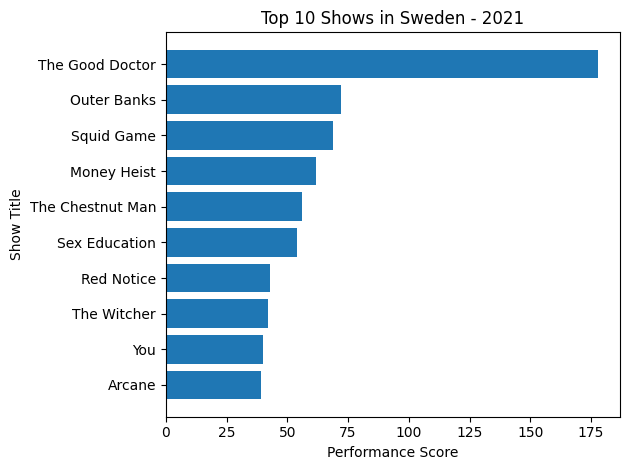

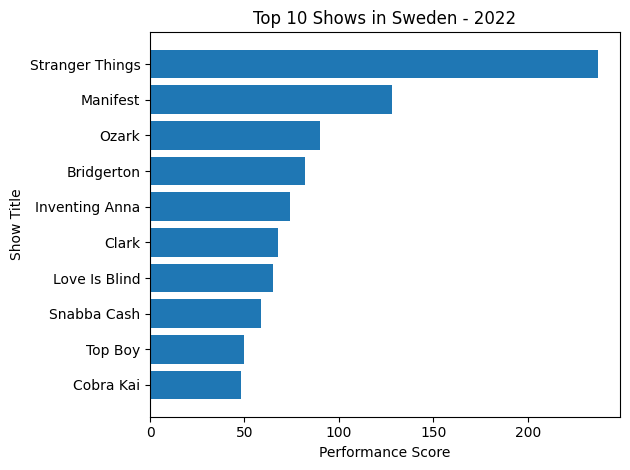

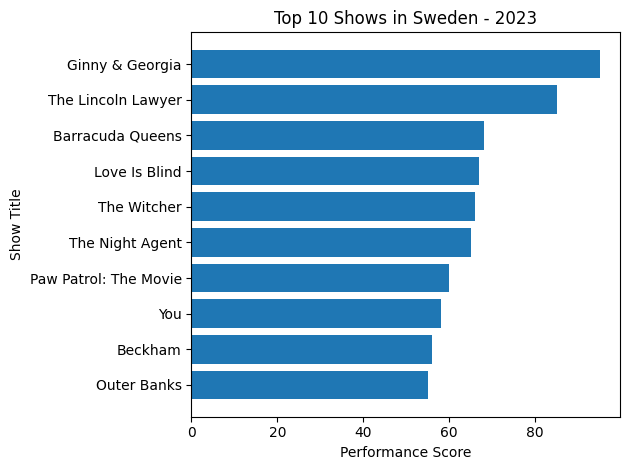

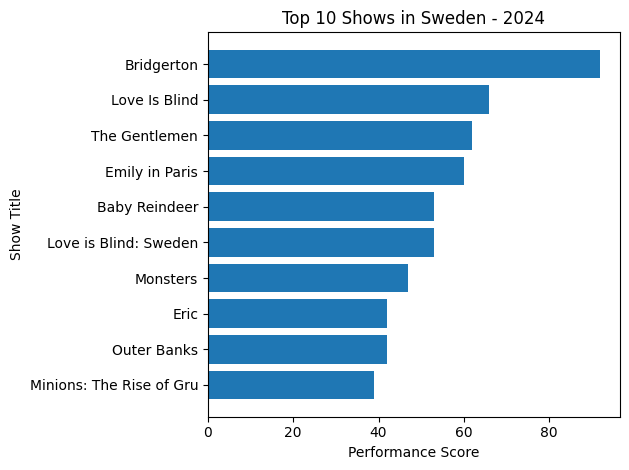

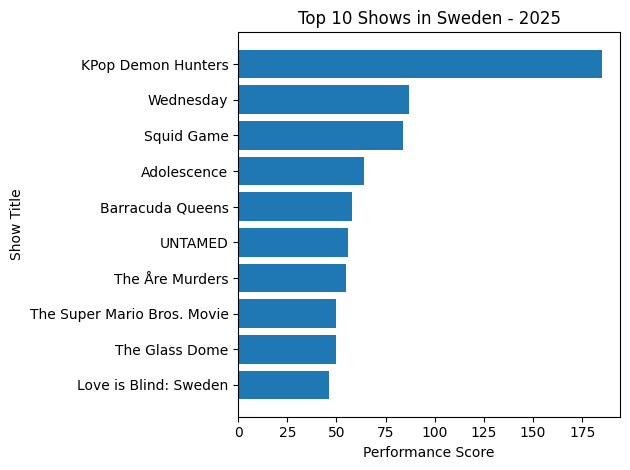

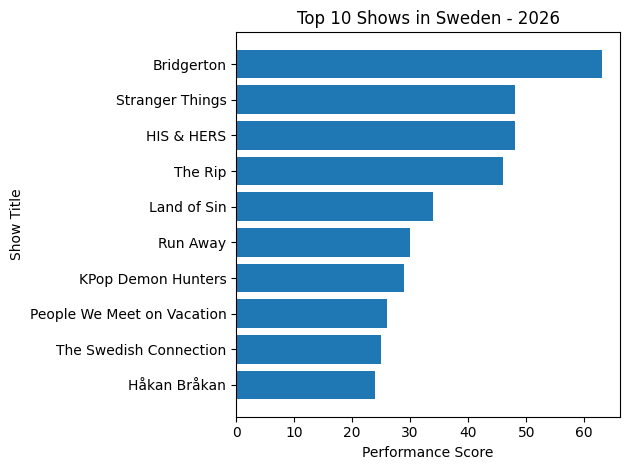

In [16]:
years = sorted(sweden_yearly_top10["year"].unique())

for year in years:
    subset = sweden_yearly_top10[sweden_yearly_top10["year"] == year]

    plt.figure()
    plt.barh(subset["show_title"], subset["yearly_score"])
    plt.gca().invert_yaxis()  # highest on top

    plt.title(f"Top 10 Shows in Sweden - {year}")
    plt.xlabel("Performance Score")
    plt.ylabel("Show Title")

    plt.tight_layout()
    plt.show()

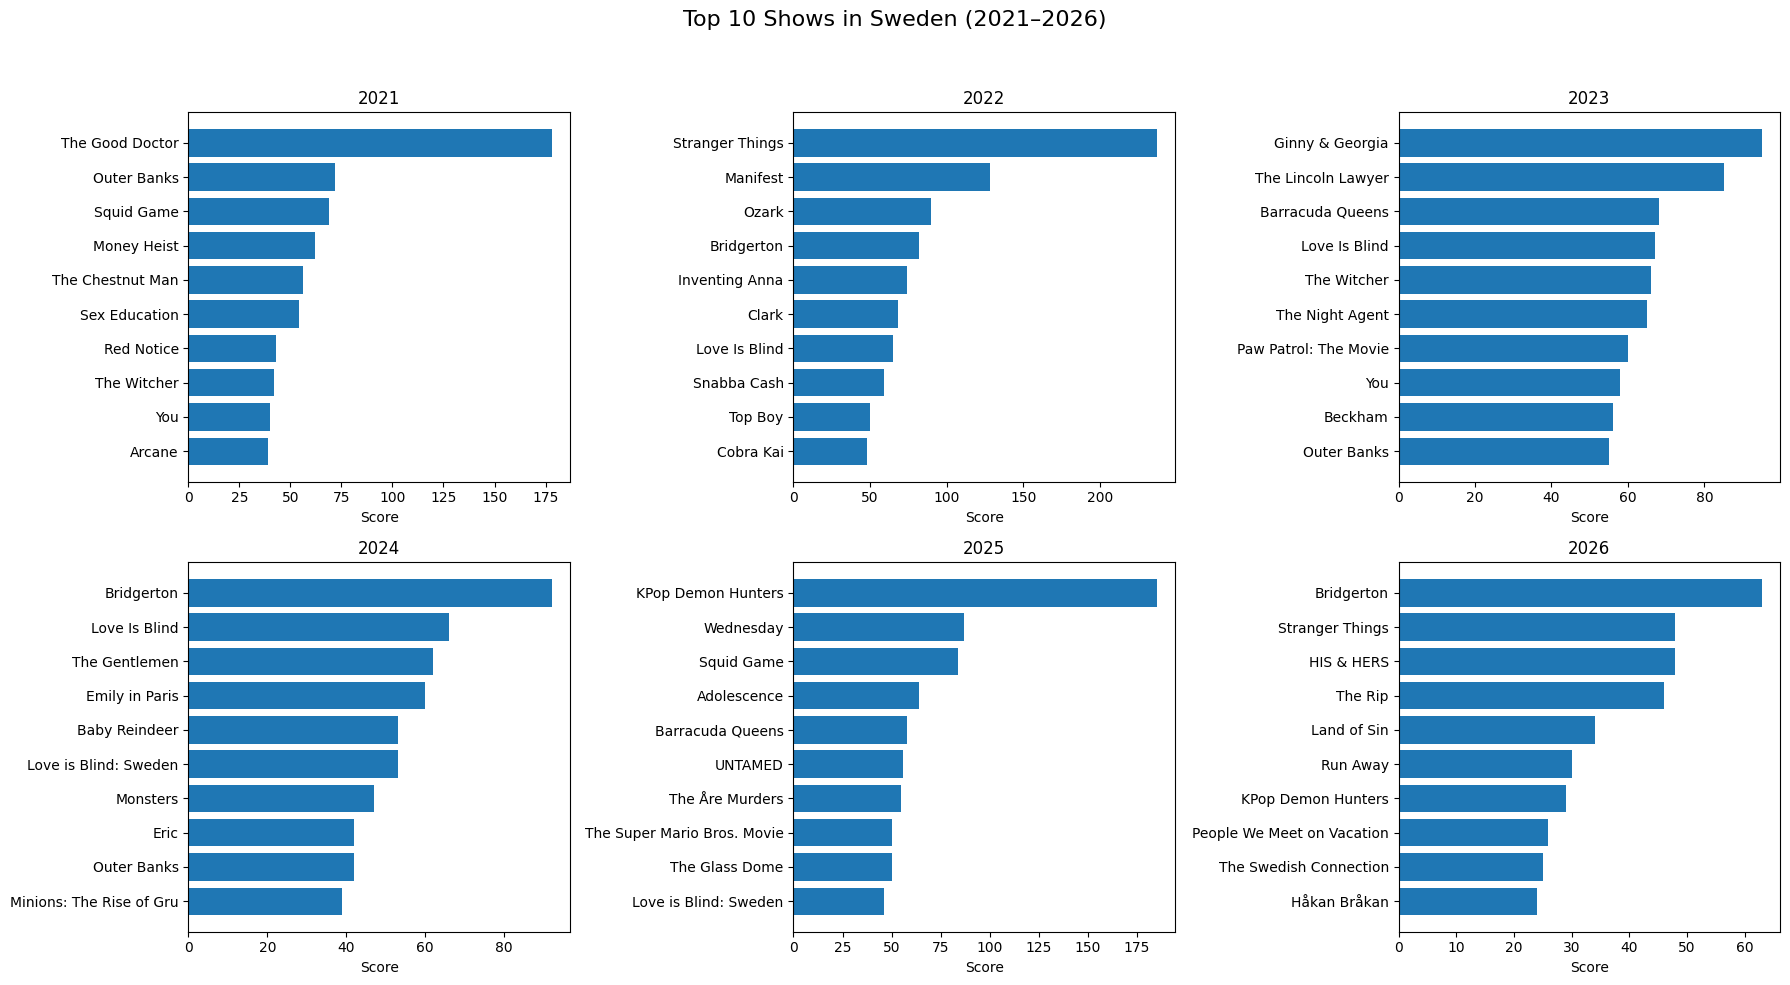

In [17]:
years = sorted(sweden_yearly_top10["year"].unique())

# Create a 2x3 grid (adjust if needed)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # flatten for easy iteration

for i, year in enumerate(years):
    subset = sweden_yearly_top10[sweden_yearly_top10["year"] == year]

    ax = axes[i]
    ax.barh(subset["show_title"], subset["yearly_score"])
    ax.invert_yaxis()

    ax.set_title(f"{year}")
    ax.set_xlabel("Score")
    ax.set_ylabel("")

# Remove empty subplot if less than 6 years (defensive design)
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

# Global title (executive layer)
fig.suptitle("Top 10 Shows in Sweden (2021–2026)", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Norway
## Dataframe Filter for Norway

In [18]:
df_norway = df[df["country_name"] == "Norway"].copy()

duckdb.register("norway_weekly", df_norway)

df_norway.shape

(4920, 11)

## Which shows dominated Norway in a given year + month?

In [19]:
norway_monthly_top_shows_df = duckdb.sql("""
WITH base AS (
    SELECT
        year,
        month,
        show_title,
        COUNT(*) AS appearances,
        SUM(11 - weekly_rank) AS performance_score,
        MAX(cumulative_weeks_in_top_10) AS longevity,
        ROUND(AVG(weekly_rank), 2) AS avg_rank
    FROM norway_weekly
    GROUP BY year, month, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year, month
            ORDER BY performance_score DESC, appearances DESC, avg_rank ASC
        ) AS monthly_rank
    FROM base
)
SELECT *
FROM ranked
WHERE monthly_rank <= 10
ORDER BY year, month, monthly_rank
""").df()

norway_monthly_top_shows_df

,year,month,show_title,appearances,performance_score,longevity,avg_rank,monthly_rank
0,2021,7,Sex/Life,4,33.0,4,2.75,1
1,2021,7,Virgin River,3,30.0,3,1.00,2
2,2021,7,Death Wish (2018),4,29.0,4,3.75,3
3,2021,7,Young Royals,4,26.0,4,4.50,4
4,2021,7,Warcraft,3,23.0,3,3.33,5
...,...,...,...,...,...,...,...,...
565,2026,3,The Night Agent,3,16.0,4,5.67,6
566,2026,3,Formula 1: Drive to Survive,2,15.0,2,3.50,7
567,2026,3,The Swedish Connection,2,15.0,3,3.50,8
568,2026,3,The Dinosaurs,2,14.0,2,4.00,9


## Norway's Yearly Top 10 Shows

In [20]:
norway_yearly_top10 = duckdb.sql("""
WITH yearly AS (
    SELECT
        year,
        show_title,
        SUM(performance_score) AS yearly_score
    FROM norway_monthly_top_shows_df
    GROUP BY year, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year
            ORDER BY yearly_score DESC
        ) AS yearly_rank
    FROM yearly
)
SELECT *
FROM ranked
WHERE yearly_rank <= 10
ORDER BY year, yearly_rank
""").df()

norway_yearly_top10

,year,show_title,yearly_score,yearly_rank
0,2021,The Good Doctor,111.0,1
1,2021,Maid,81.0,2
2,2021,Outer Banks,80.0,3
3,2021,Squid Game,67.0,4
4,2021,Money Heist,63.0,5
5,2021,Sex Education,57.0,6
6,2021,Virgin River,55.0,7
7,2021,The Chestnut Man,43.0,8
8,2021,The Witcher,40.0,9
9,2021,You,38.0,10


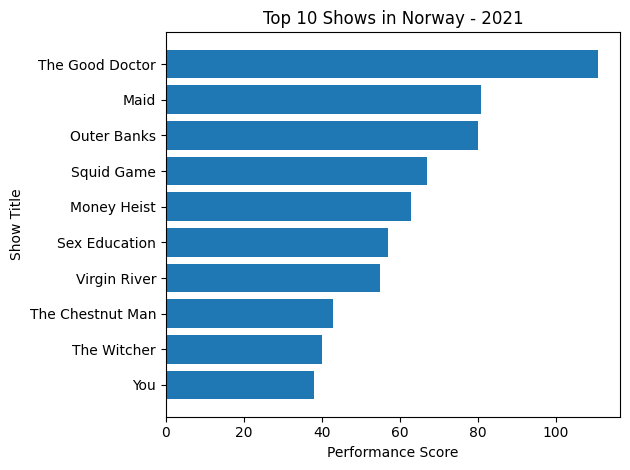

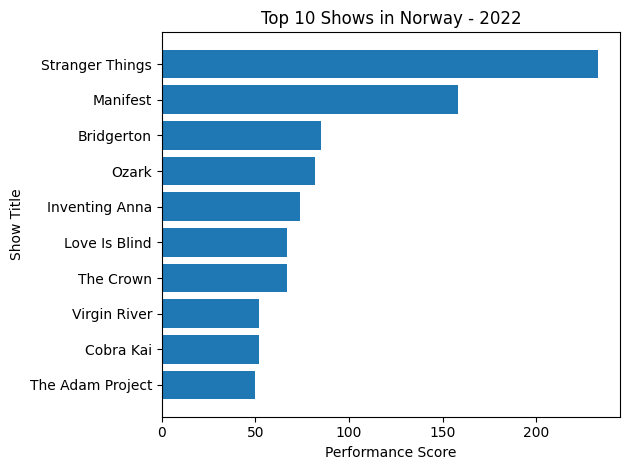

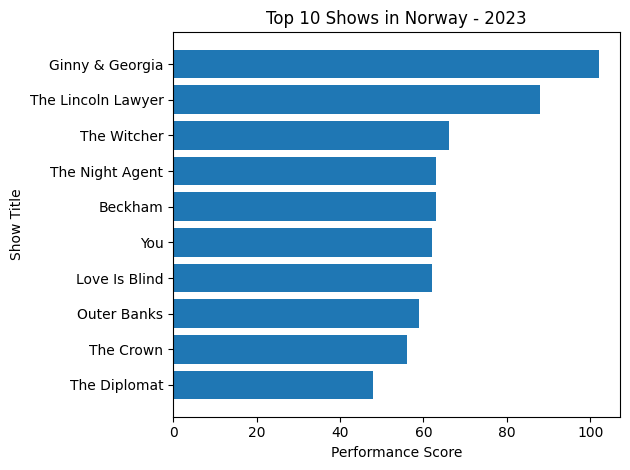

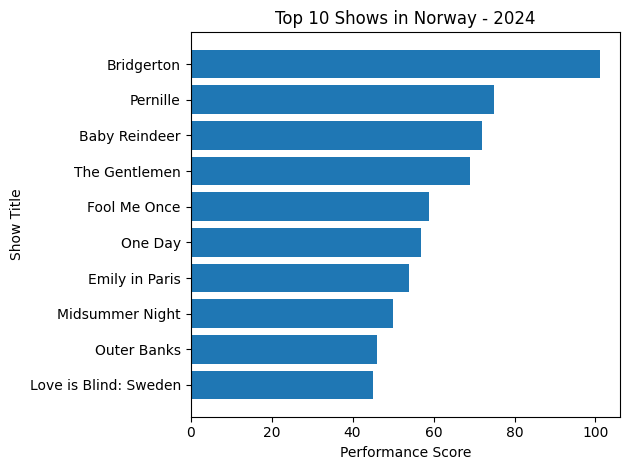

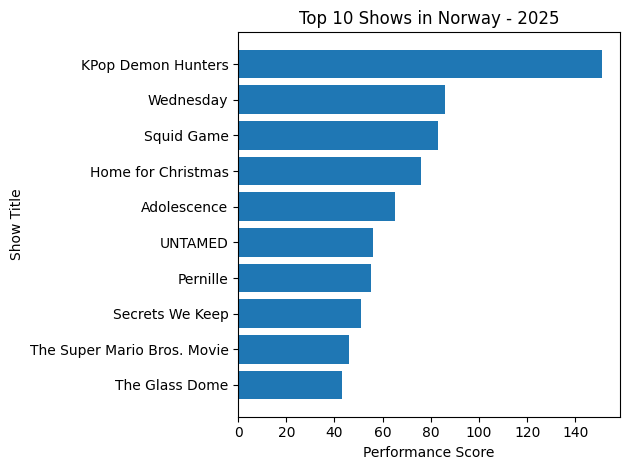

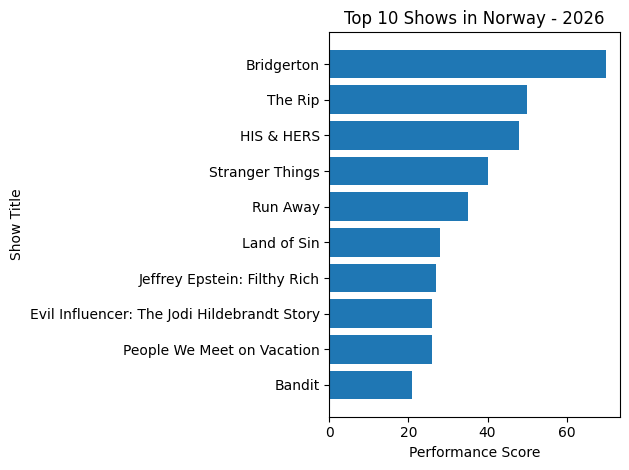

In [21]:
years = sorted(norway_yearly_top10["year"].unique())

for year in years:
    subset = norway_yearly_top10[norway_yearly_top10["year"] == year]

    plt.figure()
    plt.barh(subset["show_title"], subset["yearly_score"])
    plt.gca().invert_yaxis()

    plt.title(f"Top 10 Shows in Norway - {year}")
    plt.xlabel("Performance Score")
    plt.ylabel("Show Title")

    plt.tight_layout()
    plt.show()

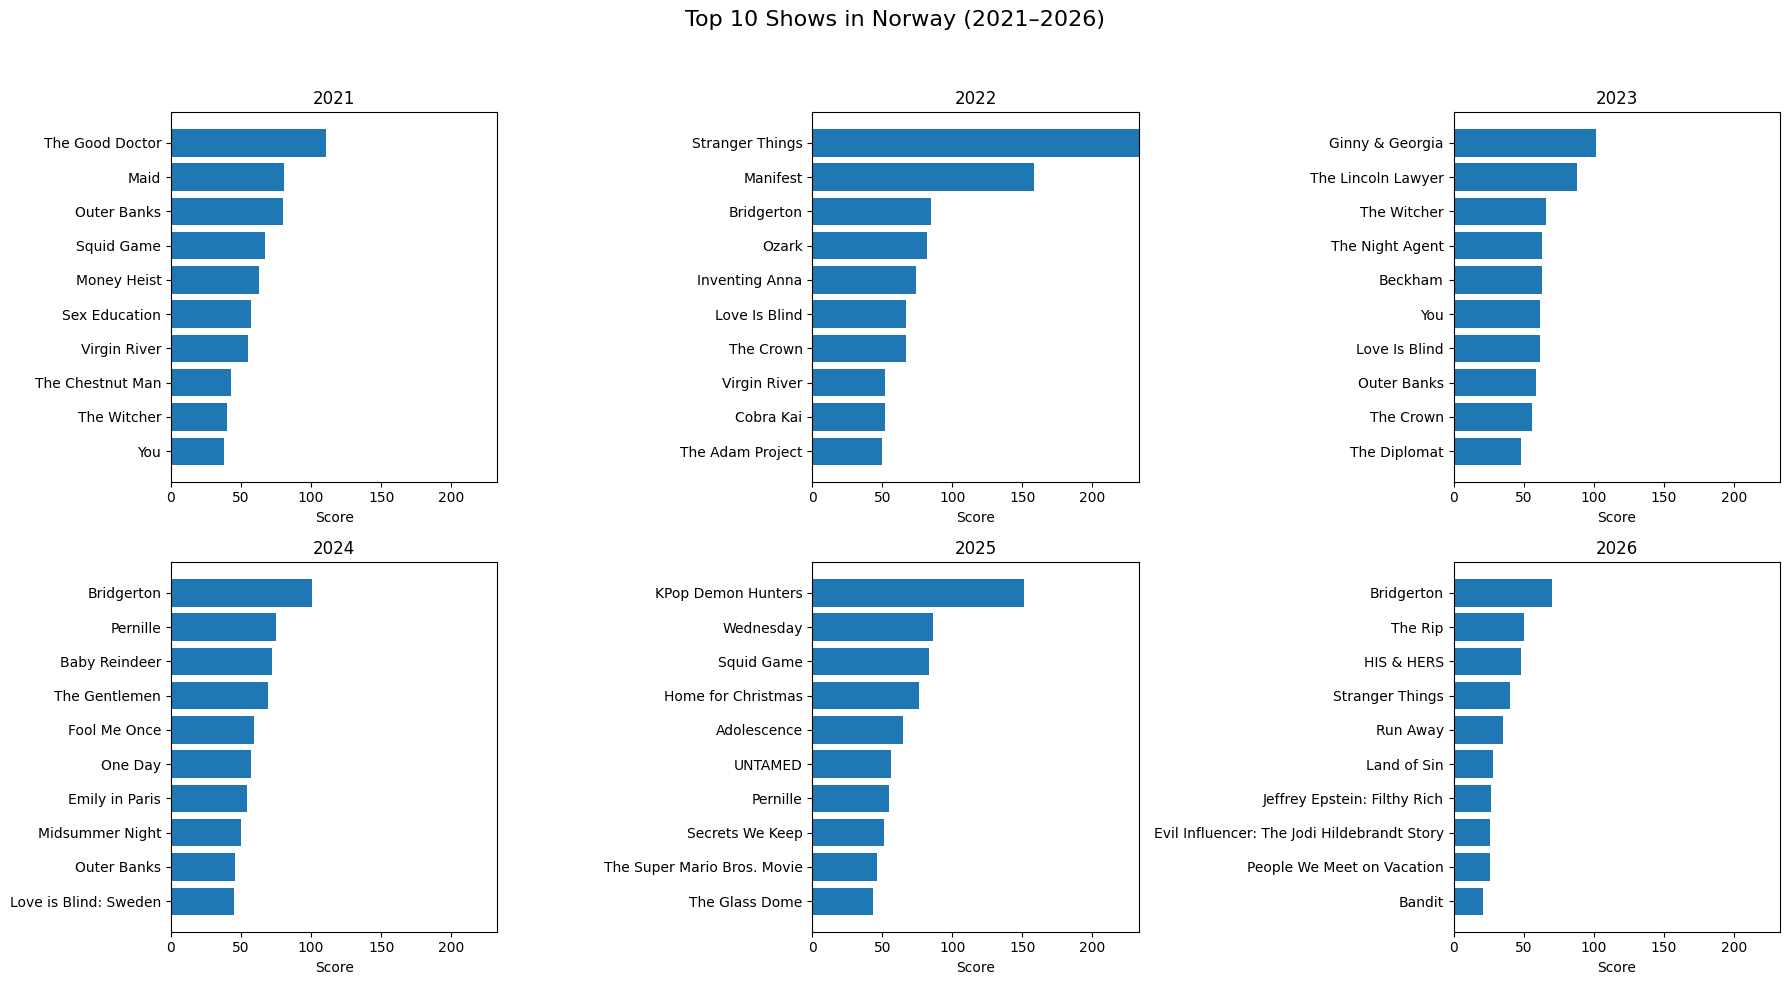

In [36]:
years = sorted(norway_yearly_top10["year"].unique())

# Create 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Optional: enforce consistent scaling across years
max_score = norway_yearly_top10["yearly_score"].max()

for i, year in enumerate(years):
    subset = norway_yearly_top10[norway_yearly_top10["year"] == year]

    ax = axes[i]
    ax.barh(subset["show_title"], subset["yearly_score"])
    ax.invert_yaxis()

    ax.set_title(f"{year}")
    ax.set_xlabel("Score")
    ax.set_ylabel("")
    
    # Keep scale consistent (important for storytelling)
    ax.set_xlim(0, max_score)

# Remove unused plots (if any)
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

# Global title
fig.suptitle("Top 10 Shows in Norway (2021–2026)", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Denmark
## Dataframe Filter for Denmark

In [22]:
df_denmark = df[df["country_name"] == "Denmark"].copy()

duckdb.register("denmark_weekly", df_denmark)

df_denmark.shape

(4920, 11)

## Which shows dominated Denmark in a given year + month?

In [23]:
denmark_monthly_top_shows_df = duckdb.sql("""
WITH base AS (
    SELECT
        year,
        month,
        show_title,
        COUNT(*) AS appearances,
        SUM(11 - weekly_rank) AS performance_score,
        MAX(cumulative_weeks_in_top_10) AS longevity,
        ROUND(AVG(weekly_rank), 2) AS avg_rank
    FROM denmark_weekly
    GROUP BY year, month, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year, month
            ORDER BY performance_score DESC, appearances DESC, avg_rank ASC
        ) AS monthly_rank
    FROM base
)
SELECT *
FROM ranked
WHERE monthly_rank <= 10
ORDER BY year, month, monthly_rank
""").df()

denmark_monthly_top_shows_df

,year,month,show_title,appearances,performance_score,longevity,avg_rank,monthly_rank
0,2021,7,Sex/Life,4,31.0,4,3.25,1
1,2021,7,Virgin River,3,28.0,3,1.67,2
2,2021,7,The Good Doctor,4,27.0,2,4.25,3
3,2021,7,Too Hot to Handle,4,27.0,4,4.25,4
4,2021,7,Warcraft,3,27.0,3,2.00,5
...,...,...,...,...,...,...,...,...
565,2026,3,Despicable Me 4,2,18.0,2,2.00,6
566,2026,3,The Dinosaurs,2,16.0,2,3.00,7
567,2026,3,KPop Demon Hunters,3,14.0,36,6.33,8
568,2026,3,Kill 'Em All 2,2,12.0,2,5.00,9


## Denmark's Yearly Top 10 Shows

In [24]:
denmark_yearly_top10 = duckdb.sql("""
WITH yearly AS (
    SELECT
        year,
        show_title,
        SUM(performance_score) AS yearly_score
    FROM denmark_monthly_top_shows_df
    GROUP BY year, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year
            ORDER BY yearly_score DESC
        ) AS yearly_rank
    FROM yearly
)
SELECT *
FROM ranked
WHERE yearly_rank <= 10
ORDER BY year, yearly_rank
""").df()

denmark_yearly_top10

,year,show_title,yearly_score,yearly_rank
0,2021,The Good Doctor,163.0,1
1,2021,Squid Game,73.0,2
2,2021,The Chestnut Man,69.0,3
3,2021,Outer Banks,67.0,4
4,2021,Sex Education,64.0,5
5,2021,Money Heist,63.0,6
6,2021,Red Notice,49.0,7
7,2021,Virgin River,42.0,8
8,2021,The Witcher,40.0,9
9,2021,You,35.0,10


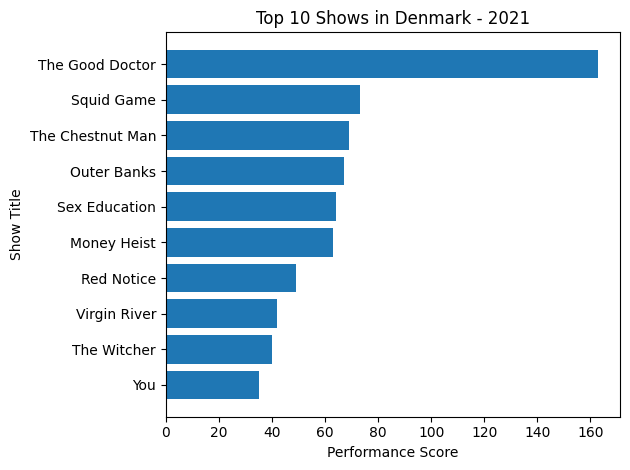

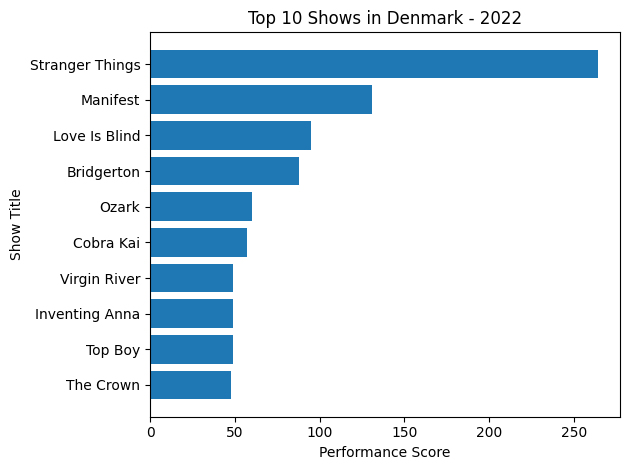

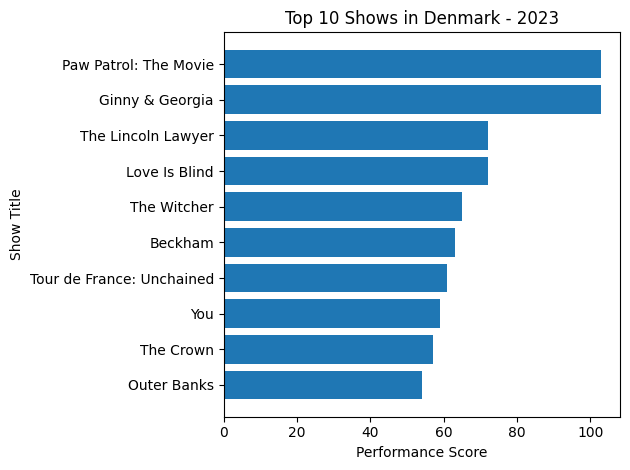

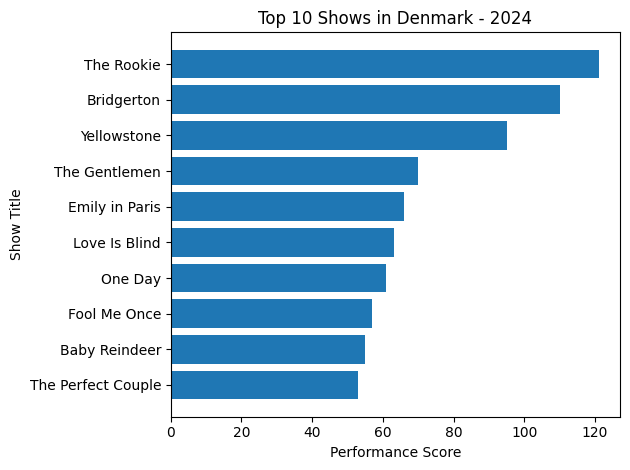

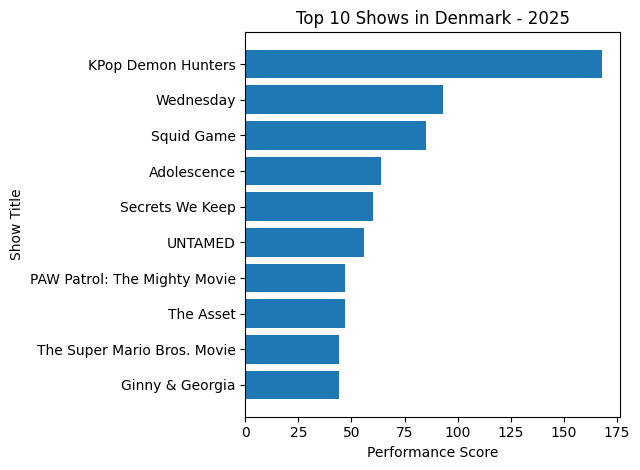

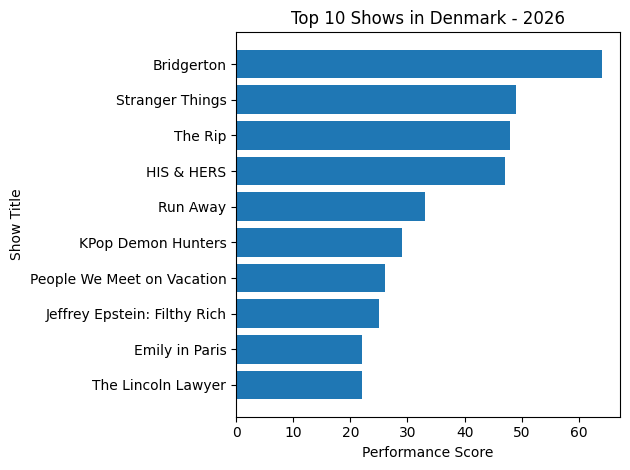

In [25]:
years = sorted(denmark_yearly_top10["year"].unique())

for year in years:
    subset = denmark_yearly_top10[denmark_yearly_top10["year"] == year]

    plt.figure()
    plt.barh(subset["show_title"], subset["yearly_score"])
    plt.gca().invert_yaxis()

    plt.title(f"Top 10 Shows in Denmark - {year}")
    plt.xlabel("Performance Score")
    plt.ylabel("Show Title")

    plt.tight_layout()
    plt.show()

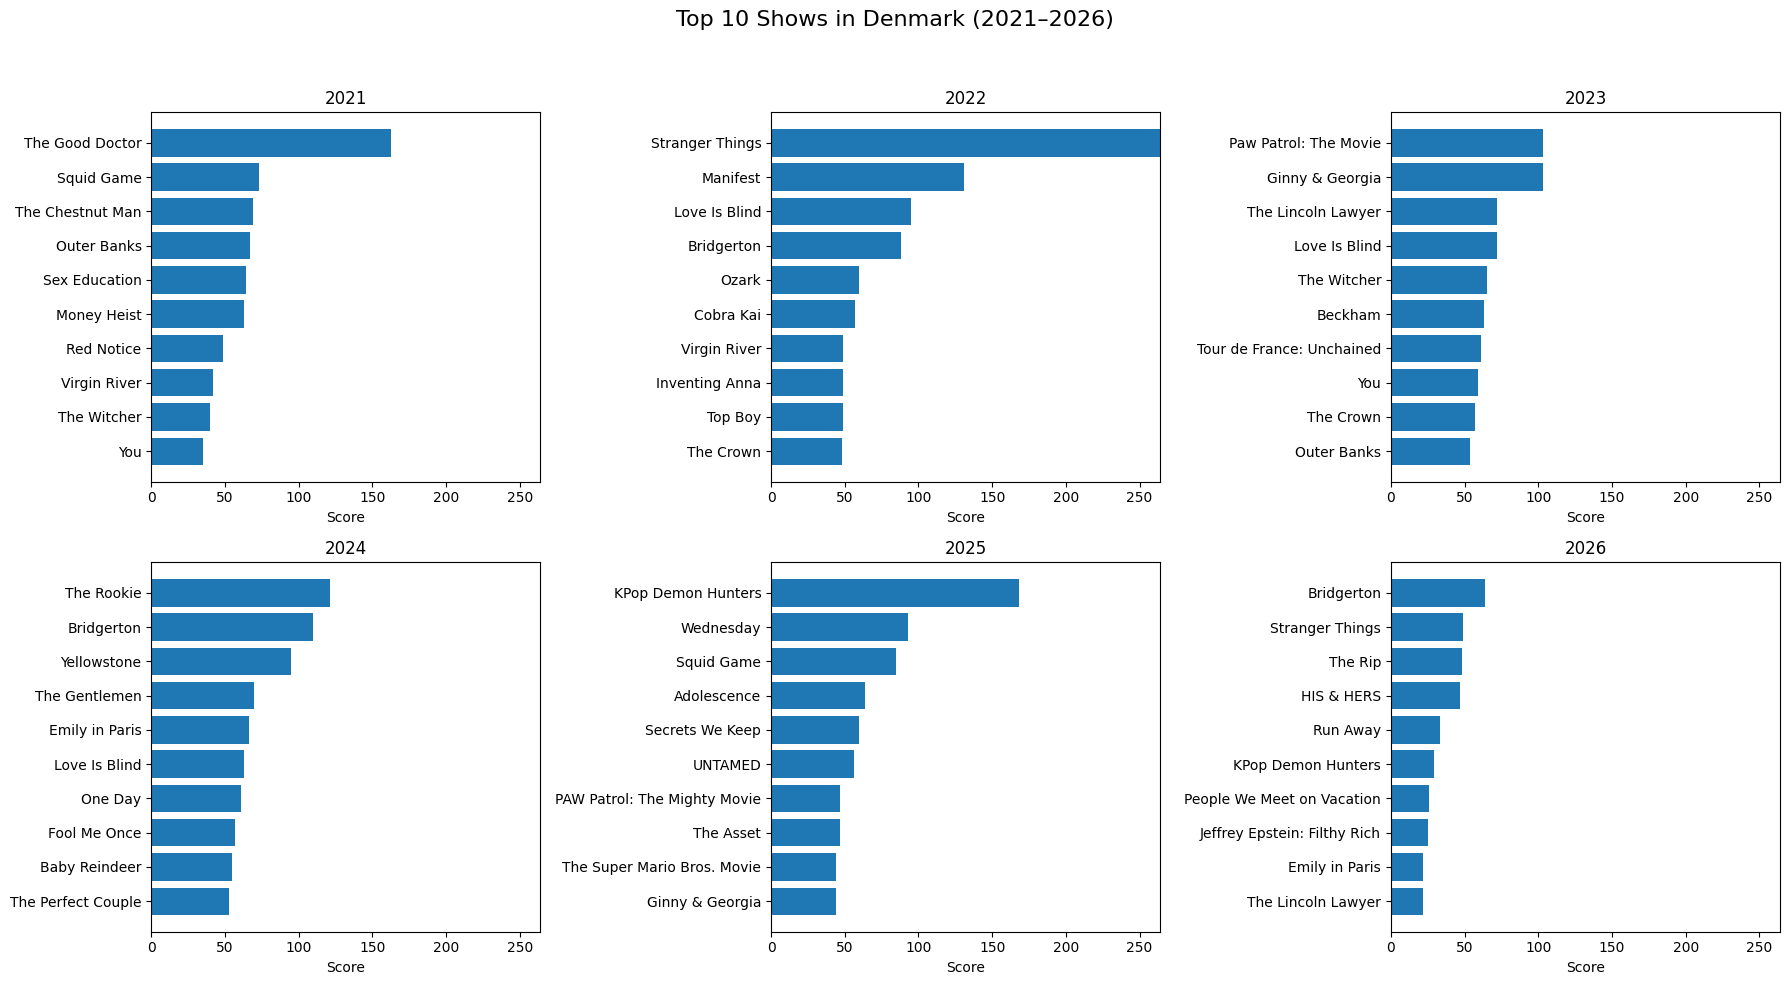

In [37]:
years = sorted(denmark_yearly_top10["year"].unique())

# Create 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Enforce consistent scaling across years
max_score = denmark_yearly_top10["yearly_score"].max()

for i, year in enumerate(years):
    subset = denmark_yearly_top10[denmark_yearly_top10["year"] == year]

    ax = axes[i]
    ax.barh(subset["show_title"], subset["yearly_score"])
    ax.invert_yaxis()

    ax.set_title(f"{year}")
    ax.set_xlabel("Score")
    ax.set_ylabel("")

    # Critical for fair comparison
    ax.set_xlim(0, max_score)

# Remove unused plots if any
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

# Executive-level title
fig.suptitle("Top 10 Shows in Denmark (2021–2026)", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Finland
## Dataframe Filter for Finland

In [26]:
df_finland = df[df["country_name"] == "Finland"].copy()

duckdb.register("finland_weekly", df_finland)

df_finland.shape

(4920, 11)

## Which shows dominated Finland in a given year + month?

In [27]:
finland_monthly_top_shows_df = duckdb.sql("""
WITH base AS (
    SELECT
        year,
        month,
        show_title,
        COUNT(*) AS appearances,
        SUM(11 - weekly_rank) AS performance_score,
        MAX(cumulative_weeks_in_top_10) AS longevity,
        ROUND(AVG(weekly_rank), 2) AS avg_rank
    FROM finland_weekly
    GROUP BY year, month, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year, month
            ORDER BY performance_score DESC, appearances DESC, avg_rank ASC
        ) AS monthly_rank
    FROM base
)
SELECT *
FROM ranked
WHERE monthly_rank <= 10
ORDER BY year, month, monthly_rank
""").df()

finland_monthly_top_shows_df

,year,month,show_title,appearances,performance_score,longevity,avg_rank,monthly_rank
0,2021,7,Sex/Life,4,32.0,4,3.00,1
1,2021,7,Death Wish (2018),4,29.0,4,3.75,2
2,2021,7,Virgin River,3,28.0,3,1.67,3
3,2021,7,The Good Doctor,4,26.0,2,4.50,4
4,2021,7,Too Hot to Handle,3,21.0,3,4.00,5
...,...,...,...,...,...,...,...,...
565,2026,3,"A Friend, a Murderer",2,15.0,2,3.50,6
566,2026,3,The Dinosaurs,2,15.0,2,3.50,7
567,2026,3,Kill 'Em All 2,2,14.0,2,4.00,8
568,2026,3,Accused,2,11.0,2,5.50,9


## Finland's Yearly Top 10 Shows

In [28]:
finland_yearly_top10 = duckdb.sql("""
WITH yearly AS (
    SELECT
        year,
        show_title,
        SUM(performance_score) AS yearly_score
    FROM finland_monthly_top_shows_df
    GROUP BY year, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year
            ORDER BY yearly_score DESC
        ) AS yearly_rank
    FROM yearly
)
SELECT *
FROM ranked
WHERE yearly_rank <= 10
ORDER BY year, yearly_rank
""").df()

finland_yearly_top10

,year,show_title,yearly_score,yearly_rank
0,2021,The Good Doctor,240.0,1
1,2021,Squid Game,80.0,2
2,2021,Money Heist,72.0,3
3,2021,Maid,55.0,4
4,2021,You,55.0,5
5,2021,Red Notice,53.0,6
6,2021,Outer Banks,51.0,7
7,2021,Sex Education,46.0,8
8,2021,The Blacklist,44.0,9
9,2021,The Witcher,36.0,10


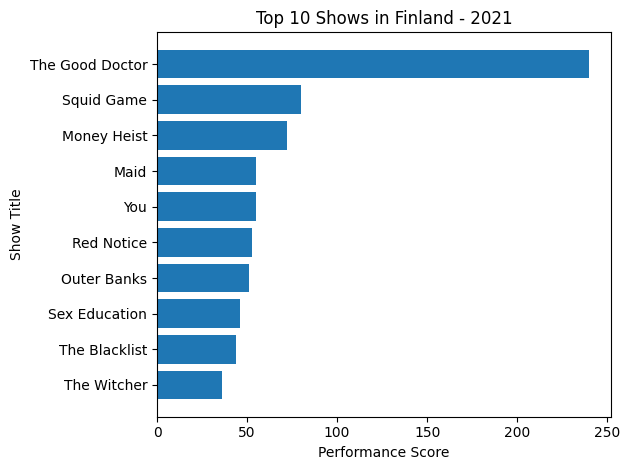

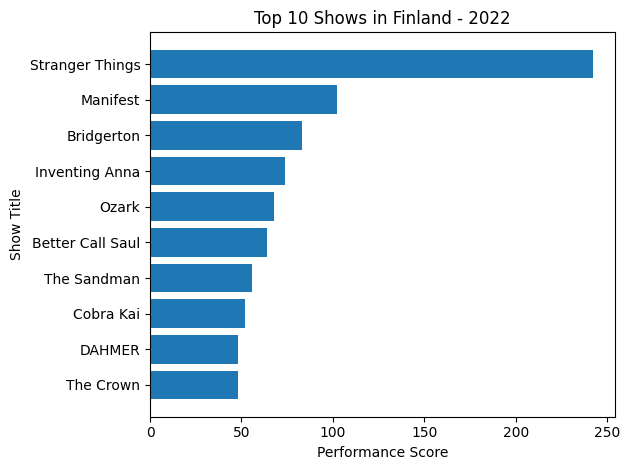

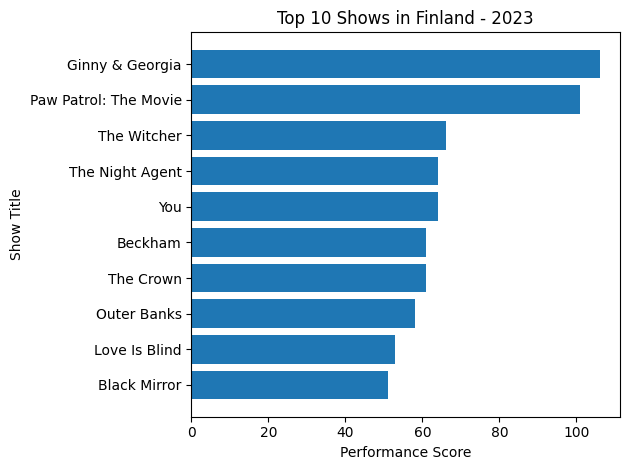

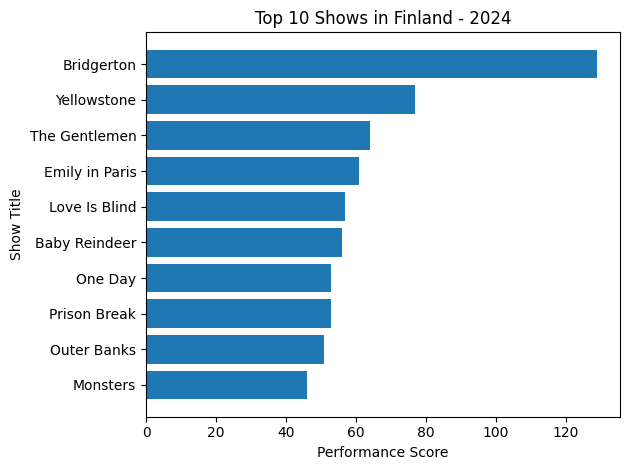

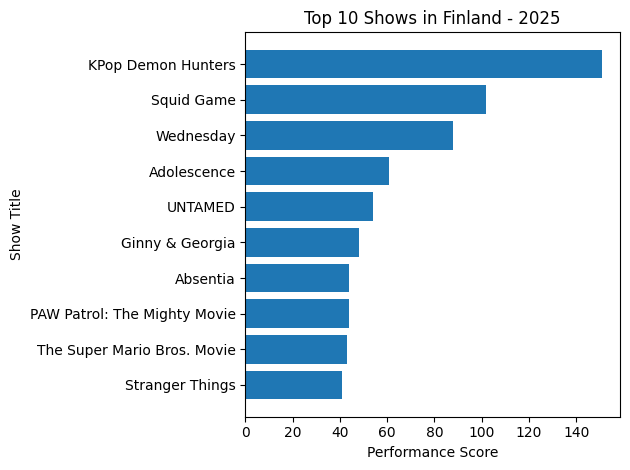

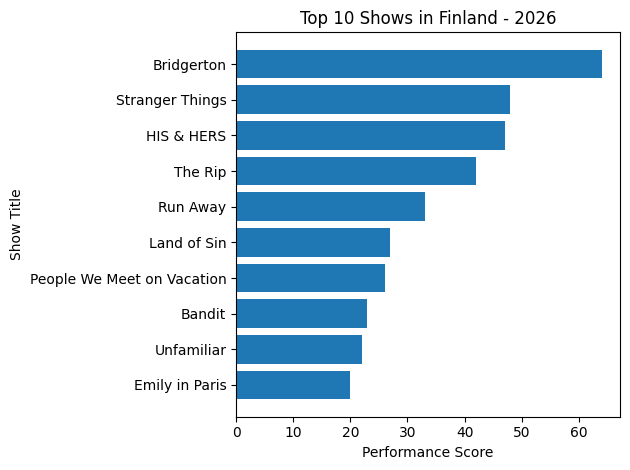

In [29]:
years = sorted(finland_yearly_top10["year"].unique())

for year in years:
    subset = finland_yearly_top10[finland_yearly_top10["year"] == year]

    plt.figure()
    plt.barh(subset["show_title"], subset["yearly_score"])
    plt.gca().invert_yaxis()

    plt.title(f"Top 10 Shows in Finland - {year}")
    plt.xlabel("Performance Score")
    plt.ylabel("Show Title")

    plt.tight_layout()
    plt.show()

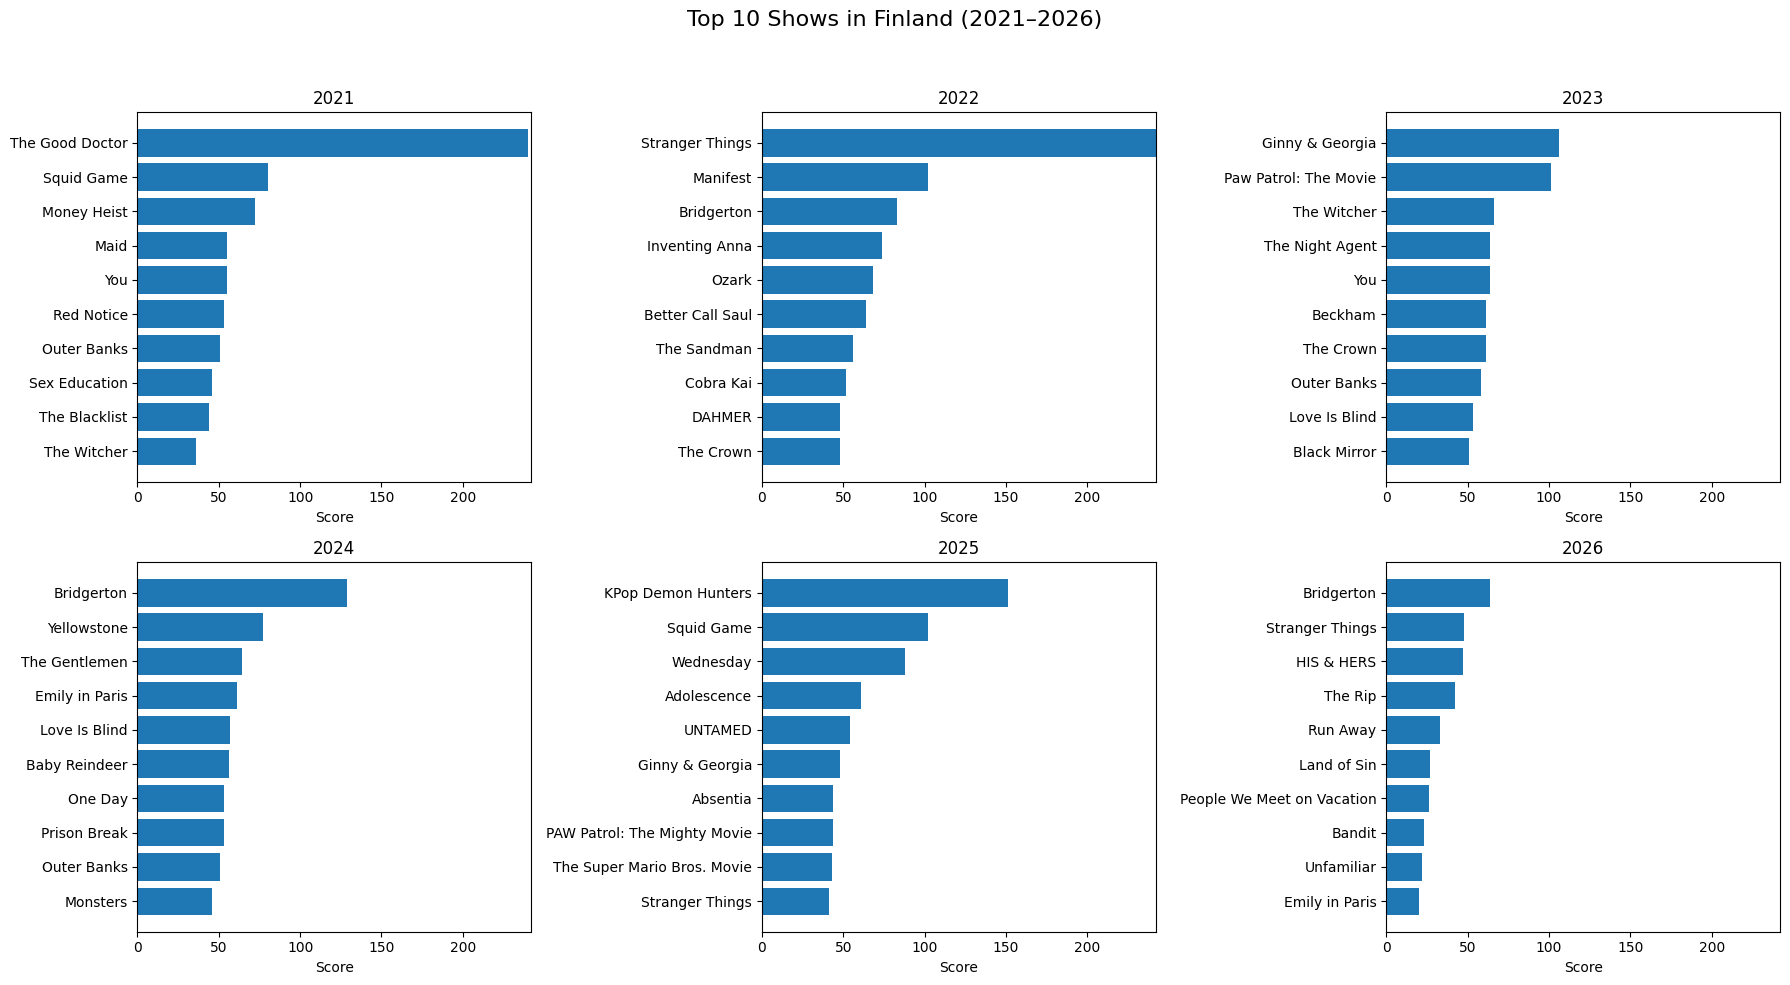

In [38]:
years = sorted(finland_yearly_top10["year"].unique())

# Create 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Enforce consistent scaling across years
max_score = finland_yearly_top10["yearly_score"].max()

for i, year in enumerate(years):
    subset = finland_yearly_top10[finland_yearly_top10["year"] == year]

    ax = axes[i]
    ax.barh(subset["show_title"], subset["yearly_score"])
    ax.invert_yaxis()

    ax.set_title(f"{year}")
    ax.set_xlabel("Score")
    ax.set_ylabel("")

    # Critical for comparability
    ax.set_xlim(0, max_score)

# Remove unused axes (defensive design)
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

# Executive-level title
fig.suptitle("Top 10 Shows in Finland (2021–2026)", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Iceland
## Dataframe Filter for Iceland

In [30]:
df_iceland = df[df["country_name"] == "Iceland"].copy()

duckdb.register("Iceland_weekly", df_iceland)

df_iceland.shape

(4920, 11)

## Which shows dominated Iceland in a given year + month?

In [31]:
iceland_monthly_top_shows_df = duckdb.sql("""
WITH base AS (
    SELECT
        year,
        month,
        show_title,
        COUNT(*) AS appearances,
        SUM(11 - weekly_rank) AS performance_score,
        MAX(cumulative_weeks_in_top_10) AS longevity,
        ROUND(AVG(weekly_rank), 2) AS avg_rank
    FROM iceland_weekly
    GROUP BY year, month, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year, month
            ORDER BY performance_score DESC, appearances DESC, avg_rank ASC
        ) AS monthly_rank
    FROM base
)
SELECT *
FROM ranked
WHERE monthly_rank <= 10
ORDER BY year, month, monthly_rank
""").df()

iceland_monthly_top_shows_df

,year,month,show_title,appearances,performance_score,longevity,avg_rank,monthly_rank
0,2021,7,New Amsterdam,7,39.0,4,5.43,1
1,2021,7,The Good Doctor,4,33.0,2,2.75,2
2,2021,7,Warcraft,3,28.0,3,1.67,3
3,2021,7,Sex/Life,4,25.0,4,4.75,4
4,2021,7,Too Hot to Handle,4,24.0,3,5.00,5
...,...,...,...,...,...,...,...,...
565,2026,3,Bandit,2,15.0,2,3.50,6
566,2026,3,The Night Agent,3,14.0,4,6.33,7
567,2026,3,Reality Check: Inside America's Next Top Model,2,12.0,3,5.00,8
568,2026,3,Vladimir,2,11.0,2,5.50,9


## Iceland's Yearly Top 10 Shows

In [32]:
iceland_yearly_top10 = duckdb.sql("""
WITH yearly AS (
    SELECT
        year,
        show_title,
        SUM(performance_score) AS yearly_score
    FROM iceland_monthly_top_shows_df
    GROUP BY year, show_title
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY year
            ORDER BY yearly_score DESC
        ) AS yearly_rank
    FROM yearly
)
SELECT *
FROM ranked
WHERE yearly_rank <= 10
ORDER BY year, yearly_rank
""").df()

iceland_yearly_top10

,year,show_title,yearly_score,yearly_rank
0,2021,The Good Doctor,216.0,1
1,2021,Maid,67.0,2
2,2021,You,61.0,3
3,2021,Outer Banks,50.0,4
4,2021,Squid Game,48.0,5
5,2021,Sex Education,46.0,6
6,2021,The Witcher,43.0,7
7,2021,New Amsterdam,39.0,8
8,2021,The Chestnut Man,33.0,9
9,2021,Good Girls,31.0,10


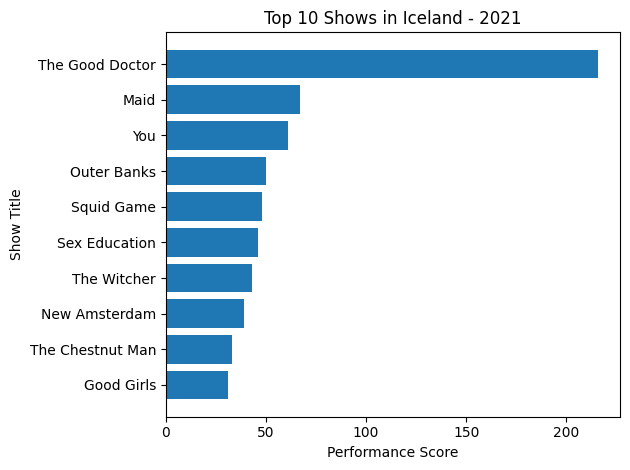

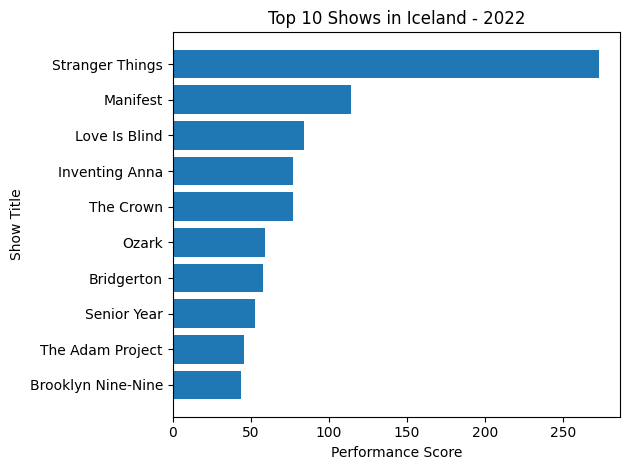

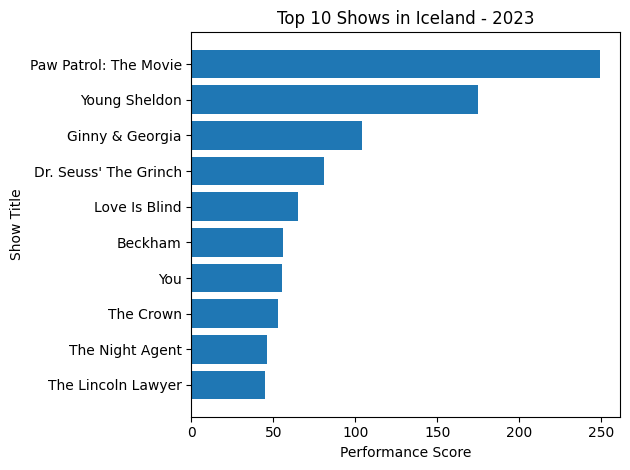

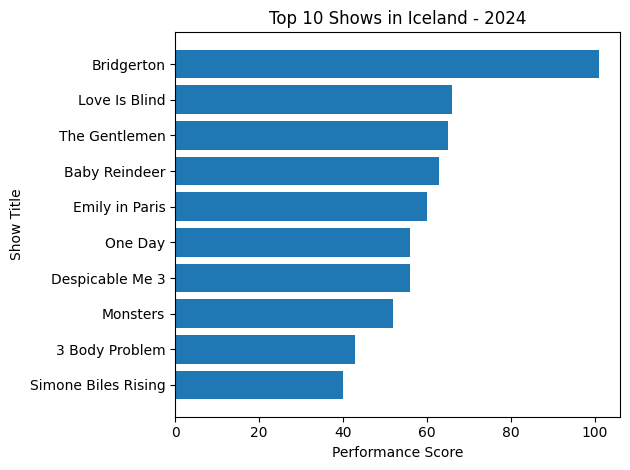

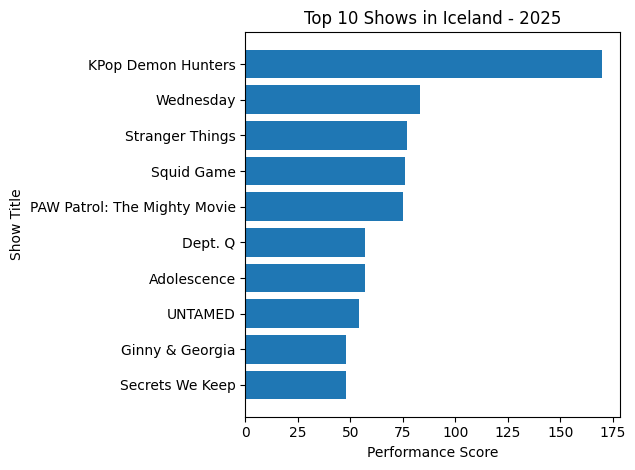

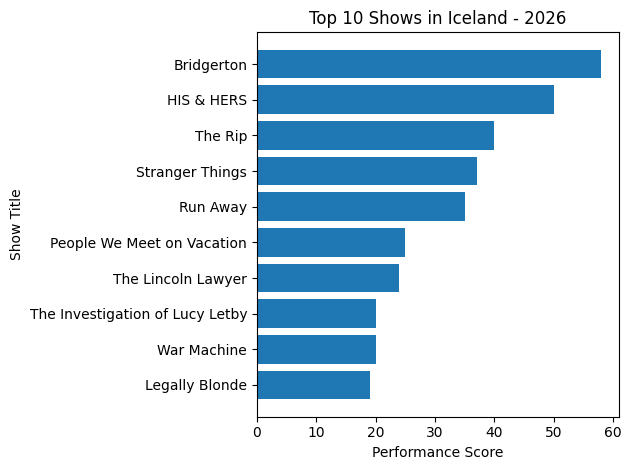

In [33]:
years = sorted(iceland_yearly_top10["year"].unique())

for year in years:
    subset = iceland_yearly_top10[iceland_yearly_top10["year"] == year]

    plt.figure()
    plt.barh(subset["show_title"], subset["yearly_score"])
    plt.gca().invert_yaxis()

    plt.title(f"Top 10 Shows in Iceland - {year}")
    plt.xlabel("Performance Score")
    plt.ylabel("Show Title")

    plt.tight_layout()
    plt.show()

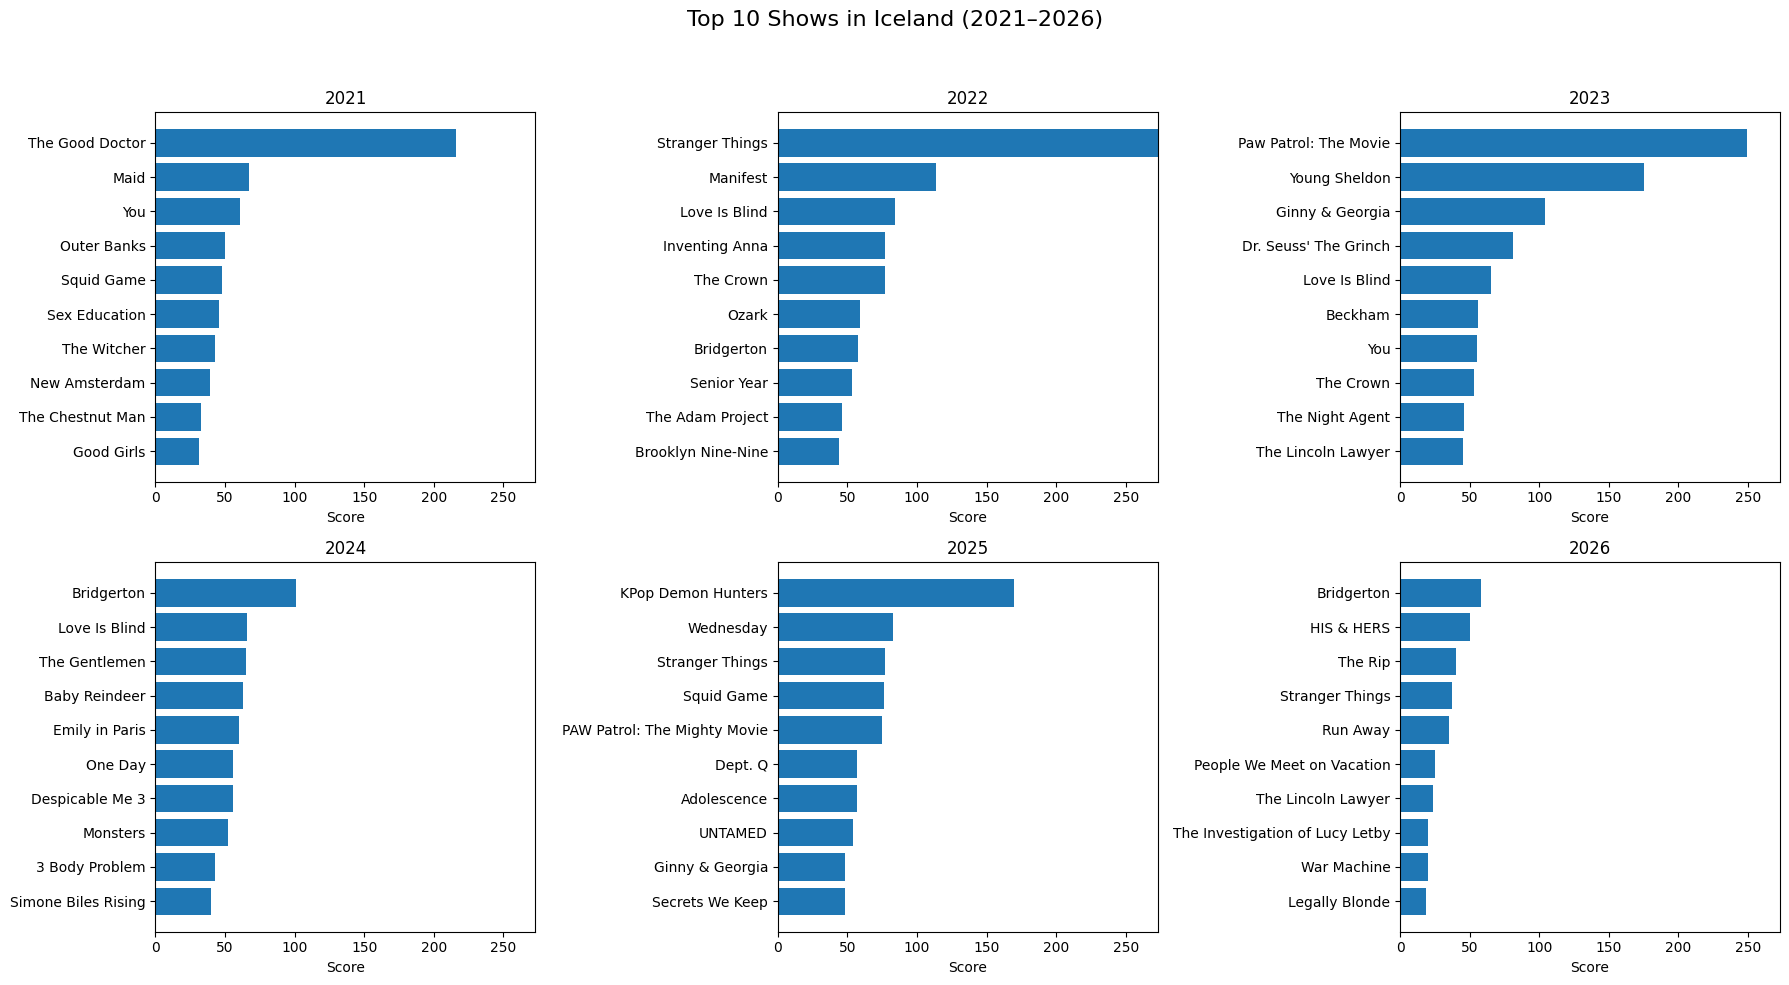

In [39]:
years = sorted(iceland_yearly_top10["year"].unique())

# Create 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Consistent scaling across years
max_score = iceland_yearly_top10["yearly_score"].max()

for i, year in enumerate(years):
    subset = iceland_yearly_top10[iceland_yearly_top10["year"] == year]

    ax = axes[i]
    ax.barh(subset["show_title"], subset["yearly_score"])
    ax.invert_yaxis()

    ax.set_title(f"{year}")
    ax.set_xlabel("Score")
    ax.set_ylabel("")

    # Critical for comparability
    ax.set_xlim(0, max_score)

# Remove unused plots if needed
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

# Executive title
fig.suptitle("Top 10 Shows in Iceland (2021–2026)", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()